# Event Organizer — Data Exploration

**Group S2 3PCO**

This notebook pulls data from three sources used in the Event Organizer pipeline and merges them into a unified contact-level view.

| Part | Source | Type |
|------|--------|------|
| 1 | **Attio CRM** | REST API |
| 2 | **OnceHub** (`go.oncehub.com/NYULeslie`) | Playwright web scraping |
| 3 | **AgentMail** | REST API / SDK |

---

**Running locally:**
```bash
doppler run -- jupyter notebook notebooks/event_organizer_exploration.ipynb
```

**Running on Colab:** Add `ATTIO_KEY`, `AGENTMAIL_API_KEY`, and `AGENTMAIL_INBOX_ID` to Colab Secrets (lock icon in left sidebar), then Runtime → Run all.

In [ ]:
# ── Install dependencies ──────────────────────────────────────────────────────
# Run this cell once. On Colab, Playwright needs an extra install step.
%pip install -q httpx pandas matplotlib nest_asyncio agentmail playwright
!playwright install chromium --with-deps -q

In [ ]:
# ── Imports & secrets ─────────────────────────────────────────────────────────
import asyncio
import os

import httpx
import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt

nest_asyncio.apply()  # Allows asyncio.run() inside Jupyter/Colab cells
%matplotlib inline


def get_secret(key: str) -> str:
    """Read a secret from Colab Secrets (Colab) or the environment (local via Doppler)."""
    try:
        from google.colab import userdata  # type: ignore
        return userdata.get(key)
    except (ImportError, Exception):
        val = os.environ.get(key)
        if not val:
            raise EnvironmentError(
                f"Missing secret: {key!r}.\n"
                "  Local: run via `doppler run -- jupyter notebook`\n"
                "  Colab: add the secret in the left-sidebar Secrets panel."
            )
        return val


ATTIO_KEY          = get_secret("ATTIO_KEY")
AGENTMAIL_API_KEY  = get_secret("AGENTMAIL_API_KEY")
AGENTMAIL_INBOX_ID = "events-technyu@agentmail.to"

print("Secrets loaded ✓")

Secrets loaded ✓


---
## Part 1 — Attio CRM

Attio is the primary CRM for the club. We fetch all people records and flatten the nested Attio response into a tidy DataFrame.

In [ ]:
# ── Fetch all people records from Attio (paginated) ───────────────────────────
# Confirmed live fields (via attribute definitions):
#   Standard : name, email_addresses, job_title, linkedin
#   Custom   : nyu_school (select), tech_nyu_cohort (text)
#   Auto     : strongest_connection_strength (select), last/first_email_interaction
# Note: club-specific fields (outreach_status, enrichment_status, etc.) are not
#       yet written to Attio — reflects attio-migration branch state.

ATTIO_BASE = "https://api.attio.com/v2"


def _v(record: dict, attr: str, key: str = "value"):
    """Extract the first value of a named attribute from an Attio record."""
    vals = record.get("values", {}).get(attr, [])
    return vals[0].get(key) if vals else None


def _select(record: dict, attr: str) -> str | None:
    """Extract the title from a select-type attribute."""
    opt = _v(record, attr, "option")
    return opt.get("title") if isinstance(opt, dict) else None


def flatten_record(record: dict) -> dict:
    """Convert nested Attio record values into a flat dict using live field slugs."""
    values = record.get("values", {})
    flat = {
        "attio_id":   record.get("id", {}).get("record_id"),
        "created_at": record.get("created_at"),
    }

    # Name
    name_vals = values.get("name", [])
    flat["firstname"] = name_vals[0].get("first_name", "") if name_vals else ""
    flat["lastname"]  = name_vals[0].get("last_name", "")  if name_vals else ""

    # Email (multiselect — take primary)
    email_vals = values.get("email_addresses", [])
    flat["email"] = email_vals[0].get("email_address") if email_vals else None

    # Text fields
    flat["job_title"]       = _v(record, "job_title")
    flat["linkedin"]        = _v(record, "linkedin")
    flat["tech_nyu_cohort"] = _v(record, "tech_nyu_cohort")

    # Select fields
    flat["nyu_school"]          = _select(record, "nyu_school")
    flat["connection_strength"] = _select(record, "strongest_connection_strength")

    # Interaction timestamps
    flat["last_email_at"]       = _v(record, "last_email_interaction",  "interaction_at")
    flat["first_email_at"]      = _v(record, "first_email_interaction", "interaction_at")
    flat["last_interaction_at"] = _v(record, "last_interaction",        "interaction_at")

    return flat


async def fetch_all_contacts(limit: int = 100) -> list[dict]:
    """Page through all people records in Attio.
    Omit the 'filter' key entirely — passing filter:{} returns 0 results.
    """
    headers = {
        "Authorization": f"Bearer {ATTIO_KEY}",
        "Content-Type": "application/json",
    }
    all_records = []
    offset = 0

    async with httpx.AsyncClient(base_url=ATTIO_BASE, headers=headers, timeout=30) as client:
        while True:
            resp = await client.post(
                "/objects/people/records/query",
                json={"limit": limit, "offset": offset},  # no filter key = all records
            )
            resp.raise_for_status()
            page = resp.json().get("data", [])
            all_records.extend(page)
            if len(page) < limit:
                break
            offset += limit

    return all_records


raw_records = asyncio.run(fetch_all_contacts())
print(f"Fetched {len(raw_records)} Attio people records")
print(f"Records exist in Attio: {len(raw_records) > 0}")

Fetched 3263 Attio people records
Records exist in Attio: True


In [ ]:
# ── Build Attio DataFrame ─────────────────────────────────────────────────────
attio_df = pd.DataFrame([flatten_record(r) for r in raw_records])
attio_df["created_at"]          = pd.to_datetime(attio_df["created_at"],          errors="coerce", utc=True)
attio_df["last_email_at"]       = pd.to_datetime(attio_df["last_email_at"],        errors="coerce", utc=True)
attio_df["first_email_at"]      = pd.to_datetime(attio_df["first_email_at"],       errors="coerce", utc=True)
attio_df["last_interaction_at"] = pd.to_datetime(attio_df["last_interaction_at"],  errors="coerce", utc=True)
attio_df["name"] = (attio_df["firstname"] + " " + attio_df["lastname"]).str.strip()

print(f"Shape: {attio_df.shape}")
attio_df[["name", "email", "nyu_school", "connection_strength", "tech_nyu_cohort", "last_email_at"]].head(10)

Shape: (3263, 14)


,name,email,nyu_school,connection_strength,tech_nyu_cohort,last_email_at
0,,sl9005@nyu.edu,None,NaN,None,NaT
1,,ak10165@nyu.edu,None,Very weak,None,NaT
2,,jz1220@nyu.edu,None,Very weak,None,NaT
3,,abc586@nyu.edu,None,NaN,None,NaT
4,,vsp7190@nyu.edu,None,NaN,None,NaT
5,Jason Yao,jasony.edu@gmail.com,None,NaN,None,NaT
6,,ic905@nyu.edu,None,NaN,None,NaT
7,Christian Stallings,cs4703@nyu.edu,None,NaN,None,NaT
8,Raabya Vasandani,rrv7875@nyu.edu,None,Very weak,None,NaT
9,,hw1635@nyu.edu,None,NaN,None,NaT


In [ ]:
attio_df[["name", "email", "nyu_school", "connection_strength", "tech_nyu_cohort", "last_email_at"]].tail(10)

,name,email,nyu_school,connection_strength,tech_nyu_cohort,last_email_at
3253,,wz2427@nyu.edu,None,Very weak,None,NaT
3254,Frank Liu,fl2211@nyu.edu,None,Very weak,None,NaT
3255,,cz2804@nyu.edu,None,Very weak,None,NaT
3256,Anatola Araba Pabst,anatola.araba@nyu.edu,None,NaN,None,NaT
3257,,mos283@nyu.edu,None,Very weak,None,NaT
3258,Abhi Agarwal,abhi.agarwal@buzzfeed.com,None,NaN,None,NaT
3259,,456andyli@gmail.com,None,Very weak,None,NaT
3260,Alexa Woods,alexa@recombine.com,None,NaN,None,NaT
3261,,myc9078@nyu.edu,None,NaN,None,NaT
3262,,jt4680@nyu.edu,None,NaN,None,NaT


In [ ]:
attio_df[["name", "email", "nyu_school", "connection_strength", "tech_nyu_cohort", "last_email_at"]].sample(10)

,name,email,nyu_school,connection_strength,tech_nyu_cohort,last_email_at
947,,bri204@nyu.edu,None,NaN,None,NaT
2869,,jc7465@nyu.edu,None,NaN,None,NaT
629,,musicbharg101@gmail.com,None,NaN,None,NaT
1507,Barry Clark,barry@dosomething.org,None,NaN,None,NaT
1646,,as15131@nyu.edu,None,NaN,None,NaT
578,Spriha Jha,spriha.jha@nyu.edu,None,Very weak,None,NaT
1317,,sj3806@nyu.edu,None,NaN,None,NaT
212,,shai@raincards.xyz,None,NaN,None,NaT
1759,,mm6158@nyu.edu,None,NaN,None,NaT
1105,,bm3291@nyu.edu,None,NaN,None,NaT


=== Field completeness (% non-null) ===
attio_id               100.0
created_at             100.0
firstname              100.0
lastname               100.0
email                  100.0
name                   100.0
connection_strength     39.9
linkedin                11.7
job_title                2.5
tech_nyu_cohort          0.0
nyu_school               0.0
last_email_at            0.0
first_email_at           0.0
last_interaction_at      0.0 



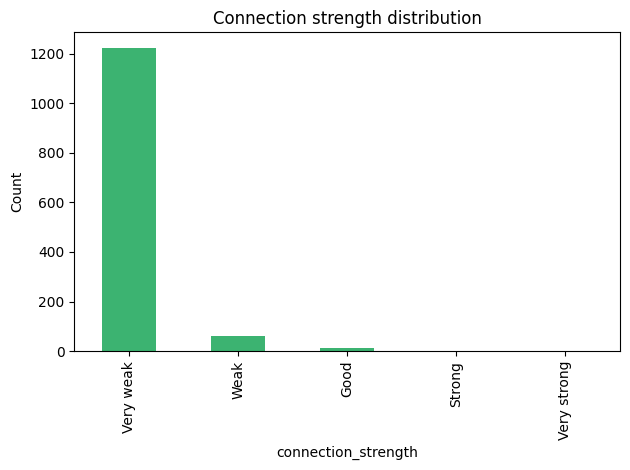

In [ ]:
# ── Attio — Data exploration ──────────────────────────────────────────────────

# Field completeness
print("=== Field completeness (% non-null) ===")
completeness = (attio_df.notna().mean() * 100).round(1).sort_values(ascending=False)
print(completeness.to_string(), "\n")

# NYU School distribution
if attio_df["nyu_school"].notna().any():
    print("=== nyu_school ===")
    print(attio_df["nyu_school"].value_counts(dropna=False).to_string(), "\n")
    attio_df["nyu_school"].value_counts().plot(
        kind="bar", title="Contacts by NYU School", color="steelblue"
    )
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Connection strength distribution
if attio_df["connection_strength"].notna().any():
    strength_order = ["Very weak", "Weak", "Good", "Strong", "Very strong"]
    counts = attio_df["connection_strength"].value_counts()
    counts = counts.reindex([s for s in strength_order if s in counts.index])
    counts.plot(kind="bar", title="Connection strength distribution", color="mediumseagreen")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Last email interaction over time
if attio_df["last_email_at"].notna().any():
    attio_df.set_index("last_email_at").resample("ME")["attio_id"].count().plot(
        kind="bar", title="Contacts by last email interaction (monthly)", color="coral"
    )
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

---
## Part 2 — OnceHub Venue Availability (Playwright)

We scrape the club's booking page at [go.oncehub.com/NYULeslie](https://go.oncehub.com/NYULeslie) using Playwright to extract available time slots for the current month.

***PLEASE RUN THIS LOCALLY**

In [6]:
!pip install playwright
!playwright install

Removing unused browser at /root/.cache/ms-playwright/firefox-1509
(node:4539) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
99.5 MiB [] 0% 0.0s99.5 MiB [] 0% 14.5s99.5 MiB [] 0% 12.0s99.5 MiB [] 0% 6.8s99.5 MiB [] 1% 5.2s99.5 MiB [] 1% 4.2s99.5 MiB [] 2% 3.8s99.5 MiB [] 2% 3.9s99.5 MiB [] 3% 3.9s99.5 MiB [] 3% 3.7s99.5 MiB [] 4% 3.6s99.5 MiB [] 5% 3.3s99.5 MiB [] 5% 3.2s99.5 MiB [] 6% 3.1s99.5 MiB [] 7% 3.1s99.5 MiB [] 8% 2.8s99.5 MiB [] 10% 2.4s99.5 MiB [] 12% 2.2s99.5 MiB [] 13% 2.1s99.5 MiB [] 14% 2.0s99.5 MiB [] 16% 1.8s99.5 MiB [] 17% 1.7s99.5 MiB [] 19% 1.6s99.5 MiB [] 20% 1.6s99.5 MiB [] 21% 1.5s99.5 MiB [] 23% 1.5s99.5 MiB [] 24% 1.4s99.5 MiB [] 26% 1.3s99.5 MiB [] 27% 1.3s99.5 MiB [] 29% 1.2s99.5 MiB [] 30% 1.2s99.5 MiB [] 32% 1.1s99.5 Mi

In [13]:
#!/usr/bin/env python3
"""
Scrape available 1.5-hour (90-minute) booking slots from the OnceHub
NYU Leslie eLab page for the next ~30 days.

Rooms scraped:
  1. Pre-money conference room (fits 12 people)
  2. Lean/Launchpad (fits 30 – 50 people)

The script:
  - Navigates to the booking page
  - Selects each room
  - Dismisses the timezone dialog (defaults to US / Eastern)
  - Selects the 90-minute duration
  - Iterates through each month that falls within the next 30 days
  - Clicks every *available* day and collects all displayed time-slot buttons
  - Outputs a JSON list of {room, date, time_slot, available} dicts

OnceHub DOM structure (AngularJS-based):
  - Calendar header: <span id="monthHeading">March 2026</span>
  - Available day buttons: <button id="dateCell_N" class="day ng-scope boldDay"
        aria-label="Show available time slots for 16 March 2026">
  - Unavailable day buttons: <button class="day ng-scope different-month"
        aria-label="No available time slots for 1 March 2026"> (no id)
  - Time slot buttons: <button id="timeSlot_N" class="timeSlotSingle ..."
        aria-label="Select 11:15 AM on Mon, Mar 16, 2026">
  - Month navigation: <button id="PrevPeriod">, <button id="NextPeriod">
"""

from __future__ import annotations

import asyncio
import json
from datetime import date, timedelta
from playwright.async_api import async_playwright, Page, TimeoutError as PwTimeout

ONCEHUB_URL = "https://go.oncehub.com/NYULeslie"
DURATION_MINUTES = 90          # change to 30, 45, 90 … as needed
LOOKAHEAD_DAYS   = 30          # scrape the next N calendar days

# Mapping from duration value to dropdown index
DURATION_INDEX = {30: 0, 45: 1, 60: 2, 75: 3, 90: 4, 105: 5, 120: 6}

MONTH_NAMES = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

ROOM_NAMES = [
    "Pre-money conference room (fits 12 people)",
    "Lean/Launchpad (fits 30 - 50 people)",
]


def _month_number(name: str) -> int:
    return MONTH_NAMES.index(name) + 1


# ─── helpers ───────────────────────────────────────────────────────────────

async def _wait_for_calendar(page: Page, timeout: int = 15_000):
    """Wait until the calendar grid has fully rendered with day buttons."""
    # Wait for the month heading to be visible
    await page.wait_for_selector("#monthHeading", state="visible", timeout=timeout)
    # Wait for at least one day button to appear in the calendar table
    await page.wait_for_selector(
        "#CalTable button.day", state="attached", timeout=timeout
    )
    # AngularJS needs ~2s after initial render to apply boldDay classes
    # and assign dateCell_N ids to available day buttons. Poll until ready.
    for _ in range(10):
        await page.wait_for_timeout(500)
        count = await page.evaluate(
            "document.querySelectorAll('button[id^=\"dateCell_\"]').length"
        )
        if count > 0:
            # Found available days; give one more beat for full render
            await page.wait_for_timeout(300)
            return
    # If no dateCell buttons found after 5s, the month may have no availability
    # — that's fine, we'll just get 0 results for this month.


async def _dismiss_timezone_dialog(page: Page):
    """If the timezone dialog pops up, accept the defaults and continue."""
    try:
        btn = await page.wait_for_selector("#tzConfirmBtn", state="visible", timeout=8_000)
        await btn.click()
        await page.wait_for_timeout(500)
        print("    [OK] Timezone dialog dismissed")
    except PwTimeout:
        print("    [--] No timezone dialog")


async def _select_duration(page: Page, minutes: int = 90):
    """Handle the 'Select a duration' dialog that appears after timezone."""
    try:
        await page.wait_for_selector("#durationConfirmBtn", state="visible", timeout=8_000)
    except PwTimeout:
        print("    [--] No duration dialog")
        return

    idx = DURATION_INDEX.get(minutes, 2)

    # Open the dropdown
    dropdown = await page.wait_for_selector(
        "input#input_meeting_duration", state="visible", timeout=5_000
    )
    await dropdown.click()
    await page.wait_for_timeout(300)

    # Click the correct option
    option_sel = f"#li_meeting_duration_{idx}"
    await page.wait_for_selector(option_sel, state="visible", timeout=3_000)
    await page.click(option_sel)
    await page.wait_for_timeout(300)

    # Confirm
    await page.click("#durationConfirmBtn")
    print(f"    [OK] Duration set to {minutes} minutes")

    # CRITICAL: wait for the calendar to fully render after duration selection
    await _wait_for_calendar(page)


async def _get_month_year(page: Page) -> tuple[str, int]:
    """Return (month_name, year) from the calendar header."""
    el = await page.wait_for_selector("#monthHeading", state="visible", timeout=5_000)
    header = (await el.inner_text()).strip()   # e.g. "March 2026"
    parts = header.split()
    return parts[0], int(parts[1])


async def _navigate_to_month(page: Page, target_month: int, target_year: int):
    """Click Next/Prev arrows until the calendar shows the target month."""
    for _ in range(24):
        month_name, year = await _get_month_year(page)
        cur_month = _month_number(month_name)
        if cur_month == target_month and year == target_year:
            return
        if (year, cur_month) < (target_year, target_month):
            await page.click("#NextPeriod")
        else:
            await page.click("#PrevPeriod")
        # Wait for the calendar to re-render after month change
        await _wait_for_calendar(page)


async def _scrape_current_month(page: Page, target_dates: set[date]) -> list[dict]:
    """
    For the currently displayed calendar month, click each available day
    that is in target_dates and collect every time-slot button.
    """
    slots: list[dict] = []
    month_name, year = await _get_month_year(page)
    month_num = _month_number(month_name)

    # Gather all available day-cell buttons using the boldDay class
    # Available days have id="dateCell_N" and class contains "boldDay"
    day_buttons = await page.query_selector_all("button.boldDay[id^='dateCell_']")

    # Fallback: try without the boldDay class filter
    if not day_buttons:
        day_buttons = await page.query_selector_all("button[id^='dateCell_']")

    print(f"    Found {len(day_buttons)} available day(s) in {month_name} {year}")

    for btn in day_buttons:
        hint = (await btn.get_attribute("aria-label")) or ""
        if "Show available time slots" not in hint:
            continue

        day_text = (await btn.inner_text()).strip()
        try:
            day_num = int(day_text)
        except ValueError:
            continue

        d = date(year, month_num, day_num)
        if d not in target_dates:
            continue

        # Click the day to reveal time slots
        await btn.click()

        # Wait for time slots to appear (they load dynamically)
        try:
            await page.wait_for_selector(
                "button[id^='timeSlot_']", state="visible", timeout=5_000
            )
        except PwTimeout:
            print(f"      {d.isoformat()} – no time slots appeared after click")
            continue

        # Small extra wait for all slots to render
        await page.wait_for_timeout(500)

        # Collect time-slot buttons (exclude mobile duplicates)
        time_buttons = await page.query_selector_all(
            "button[id^='timeSlot_']:not([id$='mobile'])"
        )
        day_slots = []
        for tb in time_buttons:
            t_text = (await tb.inner_text()).strip()
            if t_text:
                day_slots.append({
                    "date": d.isoformat(),
                    "day_of_week": d.strftime("%A"),
                    "time_slot": t_text,
                    "available": True,
                })
        slots.extend(day_slots)
        print(f"      {d.isoformat()} ({d.strftime('%A'):9s}) → {len(day_slots)} slot(s): "
              f"{', '.join(s['time_slot'] for s in day_slots)}")

    return slots


# ─── main scraper ──────────────────────────────────────────────────────────

async def scrape_oncehub(
    room_index: int = 0,
    duration: int = DURATION_MINUTES,
    lookahead: int = LOOKAHEAD_DAYS,
) -> list[dict]:
    """
    Scrape available booking slots for a single room.

    Parameters
    ----------
    room_index : int
        0 = Pre-money conference room, 1 = Lean/Launchpad
    duration : int
        Desired slot duration in minutes (30, 45, 60, 75, 90, 105, 120).
    lookahead : int
        Number of days into the future to scrape.

    Returns
    -------
    list[dict]
        Each dict: {room, date, day_of_week, time_slot, available}
    """
    room_name = ROOM_NAMES[room_index]
    today = date.today()
    end_date = today + timedelta(days=lookahead)

    # Build the set of target dates
    target_dates: set[date] = set()
    d = today
    while d <= end_date:
        target_dates.add(d)
        d += timedelta(days=1)

    # Determine which months we need to visit
    months_needed: list[tuple[int, int]] = []
    seen: set[tuple[int, int]] = set()
    d = today
    while d <= end_date:
        key = (d.year, d.month)
        if key not in seen:
            seen.add(key)
            months_needed.append(key)
        d += timedelta(days=1)

    all_slots: list[dict] = []

    async with async_playwright() as pw:
        browser = await pw.chromium.launch(headless=True)
        context = await browser.new_context(
            viewport={"width": 1280, "height": 900},
            user_agent=(
                "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
                "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
            ),
        )
        page = await context.new_page()

        # 1. Navigate to the booking page
        print(f"  Navigating to {ONCEHUB_URL} ...")
        await page.goto(ONCEHUB_URL, wait_until="networkidle", timeout=30_000)
        await page.wait_for_timeout(2_000)

        # 2. Click the desired room card
        print(f"  Selecting room: {room_name}")
        room_keyword = room_name.split("(")[0].strip()
        links = await page.query_selector_all("a")
        clicked = False
        for link in links:
            text = (await link.inner_text()) or ""
            if room_keyword.lower() in text.lower():
                await link.click()
                clicked = True
                break
        if not clicked:
            print(f"  [ERROR] Could not find room card for '{room_keyword}'")
            await browser.close()
            return []

        # Wait for the page to transition (loading spinner + dialogs)
        await page.wait_for_timeout(3_000)

        # 3. Timezone dialog
        await _dismiss_timezone_dialog(page)

        # 4. Duration dialog (this also waits for calendar to render)
        await _select_duration(page, duration)

        # 5. Verify calendar is visible
        try:
            await page.wait_for_selector("#monthHeading", state="visible", timeout=10_000)
        except PwTimeout:
            print("  [ERROR] Calendar did not render (no #monthHeading found)")
            await browser.close()
            return []

        # 6. Iterate over each required month
        for year, month in months_needed:
            print(f"  Processing {MONTH_NAMES[month-1]} {year} ...")
            await _navigate_to_month(page, month, year)
            month_slots = await _scrape_current_month(page, target_dates)
            for s in month_slots:
                s["room"] = room_name
            all_slots.extend(month_slots)

        await browser.close()

    return all_slots


# ─── Booking form field reference ──────────────────────────────────────────
#
# After selecting a time slot and clicking "Continue", the booking form
# ("Provide information" page) contains these fields:
#
# REQUIRED FIELDS (* = required):
#   1. Subject*                    (input#1_val_system, type=text)
#      Hint: "What is the meeting about?"
#   2. Your first name*            (input#2_val_system, type=text)
#   3. Your last name*             (input#60168_val, type=text)
#   4. Your NYU email*             (input#3_val_system, type=email)
#      Hint: "The scheduling confirmation will be sent to this email"
#   5. NetID*                      (input#15400_val, type=text)
#      Hint: "Please use your NYU NetID (e.g., dmf229), not your N number"
#   6. NYU Affiliation*            (combobox#input_10636_val)
#      Options: Undergrad, Masters/MD/JD, PhD Student/Candidate,
#               Post-doc Fellow/Researcher, Alumni, Faculty,
#               Staff/Administrator, Non-NYU
#   7. NYU School*                 (combobox#input_10637_val)
#      Options: Abu Dhabi, CAS, Courant, Dentistry, Gallatin, GSAS/FAS,
#               Langone/Grossman, Law, Liberal Studies, Meyers,
#               Public Health, Shanghai, Silver, SPS, Steinhardt,
#               Stern, Tandon, Tisch, Wagner, Non-NYU, Other (at NYU)
#   8. Name of Event*              (input#10734_val, type=text)
#   9. Name of Organization*       (input#10735_val, type=text)
#  10. Number of Attendees*        (input#10737_val, type=text)
#      Hint: "only current NYU can be in the Leslie eLab"
#
# OPTIONAL FIELDS:
#  11. Expected Year of Graduation (input#57698_val, type=text)
#      Hint: "For students only."
#
# SUBMIT: button "Done" (hint: "Confirm your booking request")
# ───────────────────────────────────────────────────────────────────────────


# ─── entry point ───────────────────────────────────────────────────────────

async def main():
    all_results: list[dict] = []

    for room_idx in range(2):
        print(f"\n{'='*90}")
        print(f"Scraping room {room_idx}: {ROOM_NAMES[room_idx]}")
        print(f"{'='*90}")
        slots = await scrape_oncehub(room_index=room_idx, duration=90, lookahead=30)
        all_results.extend(slots)
        print(f"  => Found {len(slots)} time-slot entries for this room\n")

    # Save to JSON
    out_path = "oncehub_slots.json"
    with open(out_path, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"\nTotal slots scraped: {len(all_results)}")
    print(f"Results saved to {out_path}")

    # Pretty-print a summary
    if all_results:
        print(f"\n{'─'*70}")
        print(f"  {'Room':38s} {'Date':12s} {'Day':10s} {'Time'}")
        print(f"{'─'*70}")
        for s in all_results:
            print(f"  {s['room'][:38]:38s} {s['date']:12s} {s['day_of_week']:10s} {s['time_slot']}")
        print(f"{'─'*70}")
    else:
        print("\nNo available slots found in the next 30 days.")


if __name__ == "__main__":
    asyncio.run(main())

RuntimeError: asyncio.run() cannot be called from a running event loop

In [ ]:
# ── Build OnceHub DataFrame ───────────────────────────────────────────────────
oncehub_df = pd.DataFrame(raw_slots)

if oncehub_df.empty:
    print("No slots scraped — the page structure may have changed. Check the selector fallback above.")
else:
    if "date" in oncehub_df.columns:
        oncehub_df["date"] = pd.to_datetime(oncehub_df["date"], errors="coerce")

    print(f"Shape: {oncehub_df.shape}")
    print(oncehub_df.head(10))

In [ ]:
# ── OnceHub — Data exploration ────────────────────────────────────────────────
if not oncehub_df.empty and "available" in oncehub_df.columns:
    print("=== Availability breakdown ===")
    print(oncehub_df["available"].value_counts().to_string(), "\n")

    if "date" in oncehub_df.columns and pd.api.types.is_datetime64_any_dtype(oncehub_df["date"]):
        by_date = oncehub_df.groupby(oncehub_df["date"].dt.date)["available"].sum()
        by_date.plot(kind="bar", title="Available slots by date", color="mediumseagreen")
        plt.ylabel("Available slots")
        plt.tight_layout()
        plt.show()
    else:
        print(oncehub_df)

---
## Part 3 — AgentMail Outreach Threads

AgentMail is used to send personalized event invitations and track replies. We pull all threads from the club inbox (`technyu@agentmail.to`) to see outreach volume and reply rates.

In [ ]:
# ── Fetch AgentMail threads ───────────────────────────────────────────────────
from agentmail import AgentMail

agentmail_client = AgentMail(api_key=AGENTMAIL_API_KEY)


def fetch_threads(inbox_id: str) -> list[dict]:
    """List all threads in the inbox and check each for replies."""
    threads_resp = agentmail_client.inboxes.threads.list(inbox_id)
    threads = threads_resp if isinstance(threads_resp, list) else getattr(threads_resp, "threads", [])

    rows = []
    for t in threads:
        thread_id  = getattr(t, "id", None)       or t.get("id")
        subject    = getattr(t, "subject", None)   or t.get("subject")
        created_at = getattr(t, "created_at", None) or t.get("created_at")

        # Pull messages to find the recipient and detect replies
        messages_resp = agentmail_client.inboxes.messages.list(inbox_id, thread_id=thread_id)
        messages = messages_resp if isinstance(messages_resp, list) else getattr(messages_resp, "messages", [])

        to_email   = None
        has_reply  = False
        sent_at    = None
        last_msg_at = None

        for msg in messages:
            direction = getattr(msg, "direction", None) or msg.get("direction")
            msg_date  = getattr(msg, "created_at", None) or msg.get("created_at")

            if direction == "outbound" and not to_email:
                to_field = getattr(msg, "to", None) or msg.get("to", [])
                if to_field:
                    to_email = to_field[0] if isinstance(to_field[0], str) else to_field[0].get("address")
                sent_at = msg_date

            if direction == "inbound":
                has_reply = True
                last_msg_at = msg_date

        rows.append({
            "thread_id":    thread_id,
            "subject":      subject,
            "to_email":     to_email,
            "sent_at":      sent_at or created_at,
            "has_reply":    has_reply,
            "last_msg_at":  last_msg_at,
        })

    return rows


thread_rows = fetch_threads(AGENTMAIL_INBOX_ID)
print(f"Fetched {len(thread_rows)} threads from AgentMail inbox")

In [ ]:
# ── Build AgentMail DataFrame ─────────────────────────────────────────────────
agentmail_df = pd.DataFrame(thread_rows)

if not agentmail_df.empty:
    agentmail_df["sent_at"]   = pd.to_datetime(agentmail_df["sent_at"],   errors="coerce", utc=True)
    agentmail_df["last_msg_at"] = pd.to_datetime(agentmail_df["last_msg_at"], errors="coerce", utc=True)

print(f"Shape: {agentmail_df.shape}")
agentmail_df.head(10)

In [ ]:
# ── AgentMail — Data exploration ──────────────────────────────────────────────
if not agentmail_df.empty:
    total  = len(agentmail_df)
    replied = agentmail_df["has_reply"].sum()
    reply_rate = replied / total * 100 if total else 0

    print(f"Total threads sent : {total}")
    print(f"Threads with reply : {replied}")
    print(f"Reply rate         : {reply_rate:.1f}%\n")

    # Sent volume over time
    if "sent_at" in agentmail_df.columns and agentmail_df["sent_at"].notna().any():
        agentmail_df.set_index("sent_at").resample("D")["thread_id"].count().plot(
            kind="bar", title="Emails sent per day", color="coral"
        )
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    # Time-to-reply distribution
    replied_df = agentmail_df[agentmail_df["has_reply"] & agentmail_df["last_msg_at"].notna()].copy()
    if not replied_df.empty:
        replied_df["hours_to_reply"] = (
            (replied_df["last_msg_at"] - replied_df["sent_at"]).dt.total_seconds() / 3600
        )
        replied_df["hours_to_reply"].plot(
            kind="hist", bins=10, title="Time to reply (hours)", color="mediumpurple"
        )
        plt.xlabel("Hours")
        plt.tight_layout()
        plt.show()

---
## Merge — Unified Contact View

Join Attio (contact enrichment) with AgentMail (outreach outcome) on `email`. OnceHub slot data is shown as a separate venue-availability table.

In [ ]:
# ── Merge Attio + AgentMail on email ─────────────────────────────────────────
attio_slim = attio_df[[
    "attio_id", "name", "email", "nyu_school",
    "connection_strength", "tech_nyu_cohort", "last_email_at"
]].copy()

agentmail_slim = agentmail_df[["to_email", "subject", "sent_at", "has_reply", "last_msg_at"]].copy()
agentmail_slim = agentmail_slim.rename(columns={"to_email": "email"})

# One row per Attio contact; attach the most recent AgentMail thread if multiple exist
if not agentmail_slim.empty:
    latest_threads = (
        agentmail_slim
        .sort_values("sent_at", ascending=False)
        .drop_duplicates(subset="email")
    )
    merged_df = attio_slim.merge(latest_threads, on="email", how="left")
else:
    merged_df = attio_slim.copy()
    merged_df[["subject", "sent_at", "has_reply", "last_msg_at"]] = None

print(f"Merged contacts shape: {merged_df.shape}")
merged_df.head(10)

In [ ]:
# ── Summary: reply rate by NYU school ────────────────────────────────────────
if "has_reply" in merged_df.columns and "nyu_school" in merged_df.columns:
    summary = (
        merged_df
        .groupby("nyu_school", dropna=False)
        .agg(
            contacts=("attio_id", "count"),
            emailed=("sent_at", lambda x: x.notna().sum()),
            replied=("has_reply", "sum"),
        )
        .assign(reply_rate=lambda df: (df["replied"] / df["emailed"].replace(0, float("nan")) * 100).round(1))
    )
    print("=== Reply rate by NYU school ===")
    print(summary.to_string())

# Connection strength of contacted vs not contacted
if "connection_strength" in merged_df.columns and "sent_at" in merged_df.columns:
    print("\n=== Connection strength: emailed vs not emailed ===")
    merged_df["was_emailed"] = merged_df["sent_at"].notna()
    print(merged_df.groupby(["connection_strength", "was_emailed"]).size().unstack(fill_value=0).to_string())

# OnceHub slot availability (standalone venue context)
print("\n=== OnceHub slot availability ===")
if not oncehub_df.empty and "available" in oncehub_df.columns:
    print(oncehub_df["available"].value_counts().rename({True: "available", False: "unavailable"}).to_string())
else:
    print("No OnceHub data available.")

---
## Part 4 — [TBD]

> **TODO:** Add a fourth data source here.
>
> Suggested merge key: `email` or `attio_id`  
> Expected columns: ...

In [ ]:
# ── Part 4: [TBD Source] ─────────────────────────────────────────────────────
# TODO: fetch data here
# tbd_df = pd.DataFrame()

# TODO: merge into merged_df
# merged_df = merged_df.merge(tbd_df, on="email", how="left")

---
## Part 5 — [TBD]

> **TODO:** Add a fifth data source here.

In [ ]:
# ── Part 5: [TBD Source] ─────────────────────────────────────────────────────
# TODO: fetch data here
# tbd2_df = pd.DataFrame()

# TODO: merge into merged_df
# merged_df = merged_df.merge(tbd2_df, on="email", how="left")